# Задача предсказания знака изменения свободной энергии связывания (ddG) на основе данных из базы SKEMPI 2.0.

В этом jupyter notebook Вы можете ознакомиться с наброском решения поставленной задачи.

Решение задачи разделено на шаги, в каждом из которых представлен код и комментарии к нему.

Поимимо блокнота в репозитории github Вы сможете найти дополнительный скрипт `esm2_embeddings.py`.

# Шаг 1 - Анализ задачи, литературный обзор

Прежде чем начать создавать модель, нужно разобраться что из себя представляют данные, а также поискать уже существующие методы и инструменты, которые могут эффективно решить задачу.

Поискав статьи на соответствующую тему я нашел множество методов, которые могут предсказывать _ΔG_ для мономеров белков, а также комплексов белков, однако мной было принято решение создать собственную реализацию для демонстрации моих навыков.

Если бы это была реальная задача, я бы воспользовался существующими инструментами.

In [1]:
#Для корректной работы необходимо скачать модель ESM-2 для создания эмбеддингов белков
!pip install fair-esm
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 43.4 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import esm
import torch
import pathlib
import os
import torch.nn.functional as F
from sklearn.metrics.pairwise import cosine_similarity

from esm import FastaBatchedDataset, pretrained
from Bio import SeqIO
from Bio.PDB import PDBParser
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

In [7]:
#Датасет скачал локально с оффициального сайта базы данных SKEMPI2
df = pd.read_csv('./skempi_v2.csv', sep=';')
df = df.rename(columns={'#Pdb': 'Pdb'})
df.head()

,Pdb,Mutation(s)_PDB,Mutation(s)_cleaned,iMutation_Location(s),Hold_out_type,Hold_out_proteins,Affinity_mut (M),Affinity_mut_parsed,Affinity_wt (M),Affinity_wt_parsed,...,koff_mut_parsed,koff_wt (s^(-1)),koff_wt_parsed,dH_mut (kcal mol^(-1)),dH_wt (kcal mol^(-1)),dS_mut (cal mol^(-1) K^(-1)),dS_wt (cal mol^(-1) K^(-1)),Notes,Method,SKEMPI version
0,1CSE_E_I,LI45G,LI38G,COR,Pr/PI,Pr/PI,5.26E-11,5.260000e-11,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
1,1CSE_E_I,LI45S,LI38S,COR,Pr/PI,Pr/PI,8.33E-12,8.330000e-12,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
2,1CSE_E_I,LI45P,LI38P,COR,Pr/PI,Pr/PI,1.02E-07,1.020000e-07,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
3,1CSE_E_I,LI45I,LI38I,COR,Pr/PI,Pr/PI,1.72E-10,1.720000e-10,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
4,1CSE_E_I,LI45D,LI38D,COR,Pr/PI,Pr/PI,1.92E-09,1.920000e-09,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1


In [8]:
df.shape

(7085, 29)

In [9]:
df.columns

Index(['Pdb', 'Mutation(s)_PDB', 'Mutation(s)_cleaned',
       'iMutation_Location(s)', 'Hold_out_type', 'Hold_out_proteins',
       'Affinity_mut (M)', 'Affinity_mut_parsed', 'Affinity_wt (M)',
       'Affinity_wt_parsed', 'Reference', 'Protein 1', 'Protein 2',
       'Temperature', 'kon_mut (M^(-1)s^(-1))', 'kon_mut_parsed',
       'kon_wt (M^(-1)s^(-1))', 'kon_wt_parsed', 'koff_mut (s^(-1))',
       'koff_mut_parsed', 'koff_wt (s^(-1))', 'koff_wt_parsed',
       'dH_mut (kcal mol^(-1))', 'dH_wt (kcal mol^(-1))',
       'dS_mut (cal mol^(-1) K^(-1))', 'dS_wt (cal mol^(-1) K^(-1))', 'Notes',
       'Method', 'SKEMPI version'],
      dtype='object')

In [10]:
df.isna().sum() #Видим, что колонки, содержащие физико-химические характеристики практически полностью заполнены NaN.

,0
Pdb,0
Mutation(s)_PDB,0
Mutation(s)_cleaned,0
iMutation_Location(s),0
Hold_out_type,3774
Hold_out_proteins,0
Affinity_mut (M),0
Affinity_mut_parsed,285
Affinity_wt (M),0
Affinity_wt_parsed,2


In [11]:
dataset = df.drop(columns=df.columns[14:]) # Я решил оставить первые 14 колонок, т.к. они содержат мало пропусков,
                                           # а также из-за того, что в этих колонках содержится достаточно информации, необходимой для предсказания

In [12]:
print('Количество уникальных комплексов: ', dataset.Pdb.nunique(), end='\n')
print('Количество уникальных мутаций: ', dataset['Mutation(s)_PDB'].nunique(), end='\n')

Количество уникальных комплексов:  348
Количество уникальных мутаций:  4707


In [13]:
print('Распределение уникальных типов PPI: ', dataset.Hold_out_type.value_counts(normalize=True), end='\n', sep='\n\n')

Распределение уникальных типов PPI: 

Hold_out_type
Pr/PI          0.407430
AB/AG          0.347025
TCR/pMHC       0.226820
AB/AG,Pr/PI    0.018725
Name: proportion, dtype: float64


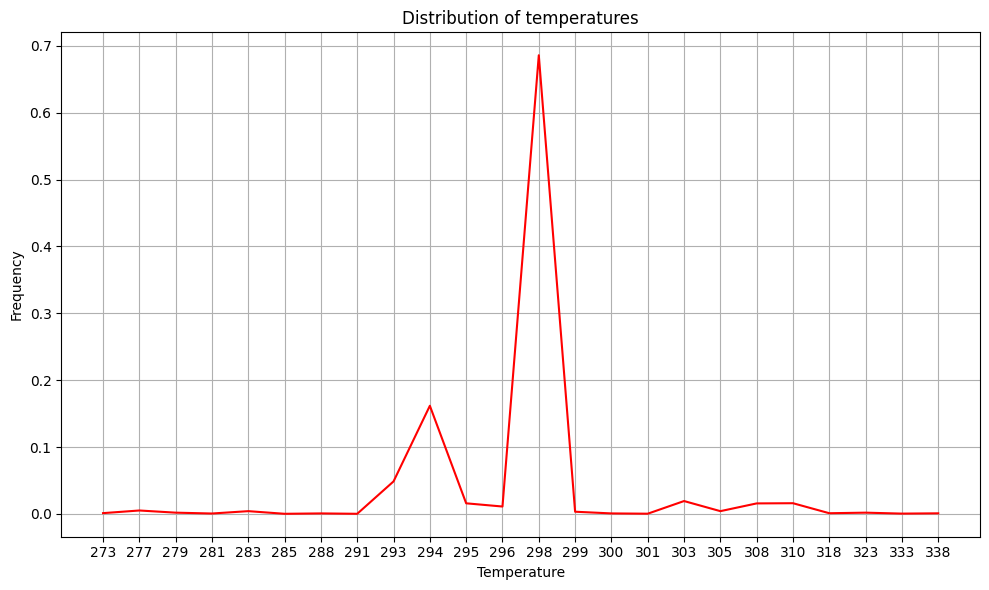

In [14]:
#Распределение темпепратур сделал для того, чтобы понять, как заполнить пропуске в колонке Temperature
dataset.loc[dataset['Temperature'] == '298(assumed)', 'Temperature'] = '298'
temparatures = dataset.Temperature.value_counts(normalize=True).sort_index()

plt.figure(figsize=(10, 6))
plt.plot(temparatures, c='red')
plt.grid(True)
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.title('Distribution of temperatures')
plt.tight_layout()
plt.show()

In [15]:
#Т.к. чаще всего эксперименты проводились при температуре 298 K, то заполняем пропуски 298
dataset['Temperature'] = dataset['Temperature'].fillna(298)

In [17]:
#Убираем строки, где неизвестна аффинность
dataset_with_ΔG = dataset[(dataset['Affinity_mut (M)'] != 'n.b.') & (dataset['Affinity_mut (M)'] != 'n.b')]
# Удаляем лишние символы
dataset_with_ΔG['Affinity_mut (M)'] = dataset_with_ΔG['Affinity_mut (M)'].str.replace('>', '')
# Удаляем строки, где NaN в колонках аффиности
dataset_with_ΔG = dataset_with_ΔG.dropna(subset=['Affinity_mut_parsed', 'Affinity_wt_parsed'], ignore_index=True)
# Приводим температуру к типу int64
dataset_with_ΔG = dataset_with_ΔG.astype({'Temperature': 'int64'})

In [18]:
#Создаем колонки, где явным образом посчитаны ΔG по формуле ΔG = RTln(Kd) / 4184, где 4184 нужно для перехода к ккал.
dataset_with_ΔG['ΔG_mut'] = np.log(dataset_with_ΔG['Affinity_mut_parsed']) * 8.314 * dataset_with_ΔG['Temperature'] / 4184
dataset_with_ΔG['ΔG_wt'] = np.log(dataset_with_ΔG['Affinity_wt_parsed']) * 8.314 * dataset_with_ΔG['Temperature'] / 4184
#Создаем колонку, где посчитана ΔΔG = ΔGmut - ΔGwt
dataset_with_ΔG['ΔΔG'] = dataset_with_ΔG['ΔG_mut'] - dataset_with_ΔG['ΔG_wt']

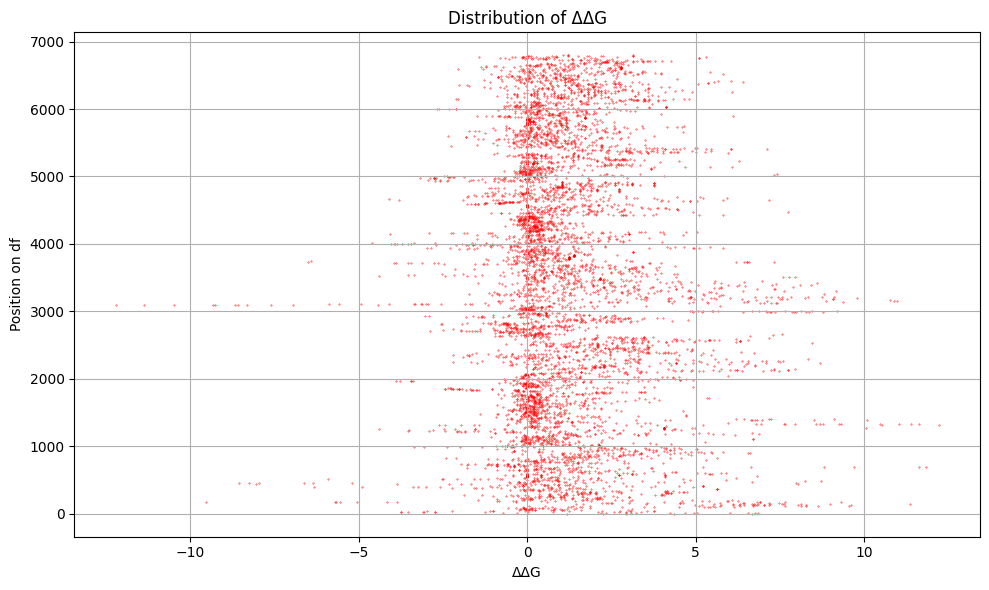

In [19]:
#Иллюстрация распределения значений ΔΔG. На глаз можно оценить, что большинство мутаций - приводят к повышению энергии

ΔΔG_x = dataset_with_ΔG['ΔΔG'].values
ΔΔG_y = dataset_with_ΔG['ΔΔG'].value_counts().index
y_range = list(range(dataset_with_ΔG.shape[0]))

plt.figure(figsize=(10, 6))
plt.scatter(ΔΔG_x, y_range, c='red', s=0.1)
plt.grid(True, which='major')
plt.xlabel('ΔΔG')
plt.ylabel('Position on df')
plt.title('Distribution of ΔΔG')
plt.tight_layout()
plt.show()

In [20]:
# Т.к. у нас задача предсказания изменения знака (т.е. + или -), то это сводится к бинарной классификации
dataset_with_ΔG['sign_ΔΔG'] = dataset_with_ΔG['ΔΔG'].apply(lambda x: 1 if x > 0 else -1)

In [21]:
# Большинство комплексов состоит из двух цепей, однако решение не подразумевает ограничений, поэтому отбор делать не нужно.
samples = pd.DataFrame(dataset_with_ΔG.Pdb)
samples['#chains'] = samples.Pdb.apply(lambda x: len(x) - 6)
samples['#chains'].value_counts()

,count
#chains,
2,4169
3,1250
4,770
5,579
8,30


# Шаг 2 - работа со структурами (извлечение аминокислотных последовательностей из PDB)

In [22]:
def extract_residues(structure):
    """Парсинг PDB файлов для извлечения последовательности аминокислот"""
    three_to_one = {
    'ALA': 'A',
    'ARG': 'R',
    'ASN': 'N',
    'ASP': 'D',
    'CYS': 'C',
    'GLN': 'Q',
    'GLU': 'E',
    'GLY': 'G',
    'HIS': 'H',
    'ILE': 'I',
    'LEU': 'L',
    'LYS': 'K',
    'MET': 'M',
    'PHE': 'F',
    'PRO': 'P',
    'SER': 'S',
    'THR': 'T',
    'TRP': 'W',
    'TYR': 'Y',
    'VAL': 'V',
    'SEC': 'U',
    'PYL': 'O',
    'ASX': 'B',
    'GLX': 'Z',
    'XAA': 'X',
    'XLE': 'J'
}
    sequences = {}
    model = structure[0]
    for chain in model:
        for residue in chain:
            if residue.resname in three_to_one:
                sequences[chain.id] = sequences.get(chain.id, '') + three_to_one[residue.resname]   #f'{residue.resname}_'

    return sequences

In [24]:
pdb_parser = PDBParser()
all_sequences = {}
for pdb_id in tqdm(dataset_with_ΔG.Pdb.unique()):
    pdb_id_split = pdb_id.split('_')[0]
    structure = pdb_parser.get_structure(f'{pdb_id_split}', f'./PDBs/{pdb_id_split}.pdb')
    seqs = extract_residues(structure)
    all_sequences[pdb_id] = seqs

100%|██████████| 344/344 [02:51<00:00,  2.00it/s]


In [25]:
# Здесь записываю в fasta файл последовательности исходных, не мутантных последовательностей цепей
fasta_name = 'sequences_orig_tmp.fasta'
with open(fasta_name, 'w') as file:
    for pdb_id, chains in all_sequences.items():
        pdb_id_split = pdb_id.split('_')[0]
        for chain in chains:
            seq = all_sequences[pdb_id][chain]
            file.write(f'>{pdb_id_split}_{chain}\n')
            file.write(f'{seq}\n')

In [26]:
def parse_mutation(mutantion: str):
    """Парсинг строки с мутацией"""
    try:
        prev_aa = mutantion[0] #Изначальная аминокислота
        chain = mutantion[1] #Мутировавшая цепь
        position = int(mutantion[2:-1]) - 1 #Позиция мутации
        new_aa = mutantion[-1] #Новая аминокислота
        return prev_aa, chain, position, new_aa
    except ValueError as e:
        raise ValueError(f"Неправильный формат мутации: {mutantion}")

def create_mutant_sequence(original_seq: str, position: int, new_aa: str) -> str:
    """Создает мутантную последовательность"""
    return original_seq[:position] + new_aa + original_seq[position+1:]

def generate_mutant_dict(all_sequences, dataset):
    """Генерирует словарь мутантных последовательностей"""
    all_sequences_mutations = {}

    for pdb_id, chains in all_sequences.items():
        pdb_id_split = pdb_id.split('_')[0]
        mutations = dataset[dataset.Pdb == pdb_id]['Mutation(s)_cleaned']

        for idx, mut_idx in enumerate(mutations.index, start=1):
            tmp = {}

            for single_mut in mutations[mut_idx].split(','):
                prev_aa, chain, position, new_aa = parse_mutation(single_mut)
                orig_sequence = all_sequences[pdb_id][chain]
                mutation_sequence = create_mutant_sequence(orig_sequence, position, new_aa)
                tmp[chain] = mutation_sequence

            all_sequences_mutations[f'{pdb_id}_{mut_idx}_{"_".join(list(tmp.keys()))[::-1]}'] = tmp

    return all_sequences_mutations

def write_fasta(all_seqs, filename):
    """Записывает мутантные последовательности в FASTA файл"""
    with open(filename, 'w') as file:
        for pdb_id, chains in all_seqs.items():
            pdb_complex, prot1, prot2, idx, *mut_chain = pdb_id.split('_')
            for chain in chains:
                seq = all_seqs[pdb_id][chain]
                file.write(f'>{pdb_complex}_{chain}_mut_{idx}\n')
                file.write(f'{seq}\n')

In [27]:
all_sequences_mutations = generate_mutant_dict(all_sequences, dataset_with_ΔG)
write_fasta(all_sequences_mutations, 'sequences_mutant_tmp.fasta')

In [28]:
dataset_for_train = dataset_with_ΔG.loc[:, ['Pdb', 'Mutation(s)_cleaned',
                                            'ΔG_mut', 'ΔG_wt', 'ΔΔG', 'sign_ΔΔG']]

In [29]:
def generate_names_embedding_original(pdb_names):
    """Вспомогательная функция для упрощенного доступа к датасету"""
    dict_pdb_complex = {}
    for pdb_name in pdb_names:
        name, prot1, prot2 = pdb_name.split('_')
        for chain in prot1:
            dict_pdb_complex[name] = dict_pdb_complex.get(name, []) + [f'{name}_{chain}']
        for chain in prot2:
            dict_pdb_complex[name] = dict_pdb_complex.get(name, []) + [f'{name}_{chain}']

    return dict_pdb_complex

def generate_names_embedding_mutant(all_sequences_mutations):
    """Вспомогательная функция для упрощенного доступа к датасету"""
    list_pdb_complex_mutant = []
    for name, chains in all_sequences_mutations.items():
        pdb_complex, prot1, prot2, idx, *mut_chain = name.split('_')
        tmp_list = []
        for chain in prot1:
            if chain not in mut_chain:
                tmp_list.append(f'{pdb_complex}_{chain}')
            else:
                tmp_list.append(f'{pdb_complex}_{chain}_mut_{idx}')
        for chain in prot2:
            if chain not in mut_chain:
                tmp_list.append(f'{pdb_complex}_{chain}')
            else:
                tmp_list.append(f'{pdb_complex}_{chain}_mut_{idx}')
        list_pdb_complex_mutant.append(tmp_list)

    return list_pdb_complex_mutant

In [30]:
pdb_names = dataset_for_train.Pdb.unique()
dict_pdb_complex = generate_names_embedding_original(pdb_names)
list_pdb_complex_mutant = generate_names_embedding_mutant(all_sequences_mutations)

dataset_for_train['PDB_complex'] = dataset_for_train['Pdb'].apply(lambda x: x[:4])
dataset_for_train['Name_embedding_original'] = dataset_for_train['PDB_complex'].map(dict_pdb_complex)
dataset_for_train['Name_embedding_mutant'] = list_pdb_complex_mutant

In [31]:
dataset_for_train.head()

,Pdb,Mutation(s)_cleaned,ΔG_mut,ΔG_wt,ΔΔG,sign_ΔΔG,PDB_complex,Name_embedding_original,Name_embedding_mutant
0,1CSE_E_I,LI38G,-13.827155,-16.075989,2.248833,1,1CSE,"[1CSE_E, 1CSE_I]","[1CSE_E, 1CSE_I_mut_0]"
1,1CSE_E_I,LI38S,-14.903760,-16.075989,1.172229,1,1CSE,"[1CSE_E, 1CSE_I]","[1CSE_E, 1CSE_I_mut_1]"
2,1CSE_E_I,LI38P,-9.404712,-16.075989,6.671276,1,1CSE,"[1CSE_E, 1CSE_I]","[1CSE_E, 1CSE_I_mut_2]"
3,1CSE_E_I,LI38I,-13.135001,-16.075989,2.940988,1,1CSE,"[1CSE_E, 1CSE_I]","[1CSE_E, 1CSE_I_mut_3]"
4,1CSE_E_I,LI38D,-11.725555,-16.075989,4.350434,1,1CSE,"[1CSE_E, 1CSE_I]","[1CSE_E, 1CSE_I_mut_4]"


# Шаг 3 - получение эмбеддингов белков

In [44]:
from esm_embedding import esm2
from esm import FastaBatchedDataset, pretrained

name_dir = './embeddings/'
os.mkdir(name_dir)
model_name = 'esm2_t30_150M_UR50D'
model, alphabet = pretrained.load_model_and_alphabet_hub(model_name)
for fasta_name in ['sequences_orig_tmp.fasta' ,'sequences_mutant_tmp.fasta']:
    sequences = [seq for seq in SeqIO.parse(fasta_name, 'fasta')]
    ids = [seq.id for seq in sequences]
    seqs = [str(seq.seq) for seq in sequences]

    esm2(ids, seqs, name_dir) #Создаем эмбеддинги белков, записываем в папку ./embeddings/

367it [03:30,  1.74it/s]


##### После того как получены векторные представления белков, я решил сделать следующее:

1) Конкатенируем все цепи комплекса в один большой эмбеддинг.
2) Усредняем, чтобы получить один вектор длиной 1*640.
3) Считаем косинусное сходство между исходным белком и мутантным белком.

##### Косинусное сходство будет нашим единственным признаком, который будем подавать на вход модели. Подход очень примитивный по нескольким причинам:

1) Хоть эмбеддинги ESM-2 содержат какую-то структурную информацию о белке, простое усреднение по всем цепям как-бы "размазывает" информацию о мутации.
2) Одного признака явно недостаточно, чтобы охватить информацию о изменении структуры белка.

# Шаг 4 - создание признака и обучение 3-х моделей ML

In [45]:
def cos_sim(mut_embed, wt_embed):
    """Считаем косинусное сходство"""
    return cosine_similarity(mut_embed.numpy().reshape(1, -1), wt_embed.numpy().reshape(1, -1))[0][0]

def load_complex(chains, name_dir):
    """Загрузка эмбеддингов исходных комплексов белков"""
    embed = torch.load(f'{name_dir}/{chains[0]}.pt')['representations'][30]

    for chain in chains[1:]:
        chain_embed = torch.load(f'{name_dir}/{chain}.pt')['representations'][30]
        embed = torch.cat((embed, chain_embed))

    return embed.mean(0)

In [46]:
list_cos_sim = []
for idx in tqdm(range(dataset_for_train.shape[0])):

    originals = dataset_for_train.iloc[idx]['Name_embedding_original']
    mutants = dataset_for_train.iloc[idx]['Name_embedding_mutant']

    orig_embed = load_complex(originals, name_dir)
    mutant_embed = load_complex(mutants, name_dir)

    cos = cos_sim(mutant_embed, orig_embed)
    list_cos_sim.append(cos)

100%|██████████| 6798/6798 [01:01<00:00, 110.61it/s]


In [53]:
X = np.array(list_cos_sim)
Y = dataset_for_train['sign_ΔΔG'].to_numpy()
Y_new = np.where(Y == -1, 0, Y) # Поменял, чтобы запустить другие модели

X_train, X_test, y_train, y_test = train_test_split(X, Y_new, random_state=42, shuffle=True, test_size=0.2, train_size=0.8)

print(X_train.shape, X_test.shape)

(5438,) (1360,)


In [55]:
model = LogisticRegression(random_state=42, fit_intercept=True)
_ = model.fit(X_train.reshape(-1, 1), y_train.reshape(-1, 1))

y_pred = model.predict(X_test.reshape(-1, 1))
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print('Accuracy: ', round(accuracy, 3))
print('F1: ', round(accuracy, 3))
print('Recall: ', round(recall, 3))
print('Precision: ', round(precision, 3))

Accuracy:  0.758
F1:  0.758
Recall:  1.0
Precision:  0.758


In [60]:
import xgboost

model = xgboost.XGBClassifier()
_ = model.fit(X_train.reshape(-1, 1), y_train.reshape(-1, 1)) # модель xgboost
y_pred = model.predict(X_test.reshape(-1, 1))

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print('Accuracy: ', round(accuracy, 3))
print('F1: ', round(accuracy, 3))
print('Recall: ', round(recall, 3))
print('Precision: ', round(precision, 3))

Accuracy:  0.749
F1:  0.749
Recall:  0.966
Precision:  0.764


In [59]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier() # модель случайного леса
_ = model.fit(X_train.reshape(-1, 1), y_train.reshape(-1, 1))

y_pred = model.predict(X_test.reshape(-1, 1))
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print('Accuracy: ', round(accuracy, 3))
print('F1: ', round(accuracy, 3))
print('Recall: ', round(recall, 3))
print('Precision: ', round(precision, 3))

Accuracy:  0.69
F1:  0.69
Recall:  0.812
Precision:  0.787


### Итоги

В данном jupyter notebook реализован код для анализа датасета, обработка данных, а также обучение модели Логистической регрессии.

Основная идея метода следующая:

1) Эмбеддинги белковых языковых моделей неявным образом кодируют информацию как о последовательности белка, так и о его структуре.
2) Изменение аминокислот (мутация) приводит к тому, что эмбеддинги меняются (так как они являются контекстными).
3) Для сравнения похожих эмбеддингов принято использовать величину _cos_sim_, которая показывает насколько сонаправлены два многомерных вектора.
4) Вычисление значений косинусного сходства между исходным и мутировавшим комплексами позволяет оценить насколько похожи эти два комплекса.
5) Для решения задачи бинарной классификации применяем несколько моделей. Наилучшей по метрикам оказалась Логистическая регрессия.

Идеи развития решения:

1) Можно обучить один регрессор, который будет предсказывать ___ΔG___, а затем подавать на вход эмбеддинги исходных и мутантных комплексов --> получаем
   ___ΔG_mut___ и ___ΔG_wt___, вычитаем одно из другого --> получаем знак изменения энергии.
2) Вместо обычного разделения выборки на _test_ и _train_, можно было бы провести кластеризацию последовательностей по гомологии (mmseqs2, CDHIT),
   чтобы избежать утечки данных.
3) Можно попробовать подобрать параметры через _optuna_ или _grid search_.
   